# **NEWS-BASED STOCK MARKET PREDICTION - DJIA**

---

**Professeurs :** Mohamed El Fakir & Nicolas de Roux

**Objectif :** Prédire la direction du Dow Jones Industrial Average (hausse/baisse) à partir de titres de news Reddit et de features financières.

**Collaborateurs :** Akram Boudebouze, Alexander Besson, Ferdinand Carsoux, Raphaël Essengue

---

## Architecture du projet

| Étape | Contenu |
|---|---|
| **1 - Exploration** | Chargement, Data Preparation, Visualisation Graphique |
| **2 - Feature Engineering** | TF-IDF, Features financières (yfinance), Sentiment (VADER) |
| **3 - Modélisation** | Niveau 1 : Classiques - Niveau 2 : Word2Vec - Niveau 3 : FinBERT Transformer |
| **4 - Interprétation** | Feature importance, Analyse Economique |

---
# **Étape 1 - Exploration des données**

**Objectifs :**
1. Installer les dépendances
2. Charger et nettoyer le dataset
3. Télécharger les prix DJIA via `yfinance`
4. Visualiser la distribution et le contenu textuel

### 1.1 - Installation des dépendances

In [4]:
# Installation de toutes les librairies nécessaires au projet
!pip install -q yfinance vaderSentiment gensim sentence-transformers transformers torch scikit-learn pandas matplotlib seaborn

### 1.2 - Imports globaux

In [5]:
# ── Manipulation de données ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Données financières ───────────────────────────────────────────────────────
import yfinance as yf

# ── NLP ───────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

### 1.3 - Chargement du dataset

Le dataset `Combined_News_DJIA.csv` contient :
- **1 ligne = 1 jour de bourse**
- **27 colonnes** : `Date`, `Label` (cible binaire), `Top1` à `Top25` (titres Reddit/WorldNews)
- **Période** : août 2008 → juillet 2016 (8 ans de données)

In [6]:
# Chargement
df = pd.read_csv('Combined_News_DJIA.csv')

print(f"Dimensions    : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Période       : {df['Date'].min()} → {df['Date'].max()}")
print(f"Variable cible: {df['Label'].value_counts().to_dict()}")
print(f"Proportion hausse : {df['Label'].mean()*100:.1f}%")
print()

# Valeurs manquantes
mv = df.isnull().sum()
print("Valeurs manquantes :")
print(mv[mv > 0])

Dimensions    : 1989 lignes × 27 colonnes
Période       : 2008-08-08 → 2016-07-01
Variable cible: {1: 1065, 0: 924}
Proportion hausse : 53.5%

Valeurs manquantes :
Top23    1
Top24    3
Top25    3
dtype: int64


### 1.4 - Nettoyage du texte

In [7]:
def clean_text(text):
    """
    Nettoyage robuste des titres de news.
    Supprime le préfixe b'...' ou b"..." hérité du scraping Python 2.
    Gère les guillemets simples, doubles, et les cas limites.
    """
    if pd.isna(text):
        return ''
    text = str(text).strip()

    # Cas 1 : b"texte" ou b'texte'
    match = re.match(r'^b[\'"](.+)[\'"]$', text, flags=re.DOTALL)
    if match:
        text = match.group(1)

    # Cas 2 : b""texte"" (double guillemets échappés — format CSV Kaggle)
    match2 = re.match(r'^b""(.+)""$', text, flags=re.DOTALL)
    if match2:
        text = match2.group(1)

    # Nettoyage résiduel : séquences d'échappement
    text = text.replace("\\'", "'").replace('\\"', '"')
    return text.strip()


# Application sur toutes les colonnes news
news_cols = [f'Top{i}' for i in range(1, 26)]
for col in news_cols:
    df[col] = df[col].apply(clean_text)

# Conversion date + feature temporelle
df['Date']  = pd.to_datetime(df['Date'])
df['annee'] = df['Date'].dt.year

# Concaténation des 25 titres en un texte unique par jour
df['texte_complet'] = df[news_cols].apply(lambda row: ' '.join(row.values), axis=1)

# ── Vérification du fix ────────────────────────────────────────────────────────
exemple_avant = "b\"Georgia 'downs two Russian warplanes' as countries move to brink of war\""
exemple_apres = clean_text(exemple_avant)

print("=== Bug fix V1 → V2 ===")
print(f"Avant : {exemple_avant[:70]}")
print(f"Après : {exemple_apres[:70]}")
print()
print(f"Exemple réel Top1 J1 : {df['Top1'].iloc[0][:80]}")
print(f"Valeurs manquantes restantes : {df[news_cols].isnull().sum().sum()}")

# Vérification : plus aucun token parasite b' dans les données
parasites = df['texte_complet'].str.contains(r"\bb'", regex=True).sum()
print(f"Lignes avec préfixe b' résiduel : {parasites} (doit être 0)")

=== Bug fix V1 → V2 ===
Avant : b"Georgia 'downs two Russian warplanes' as countries move to brink of 
Après : Georgia 'downs two Russian warplanes' as countries move to brink of wa

Exemple réel Top1 J1 : Georgia 'downs two Russian warplanes' as countries move to brink of war
Valeurs manquantes restantes : 0
Lignes avec préfixe b' résiduel : 0 (doit être 0)


### 1.5 - Téléchargement des prix DJIA (yfinance)

On récupère les cours historiques du DJIA sur la même période que le dataset de news.  
Ces données serviront à l'Étape 2 pour construire les features financières.

In [8]:
# Téléchargement des cours DJIA (^DJI) sur Yahoo Finance
# On prend une fenêtre légèrement plus large pour calculer les features glissantes
print("Téléchargement des cours DJIA...")
djia_raw = yf.download("^DJI", start="2007-12-01", end="2016-08-01", progress=False)

# Aplatissement du MultiIndex si nécessaire (yfinance >= 0.2)
if isinstance(djia_raw.columns, pd.MultiIndex):
    djia_raw.columns = djia_raw.columns.get_level_values(0)

djia = djia_raw[['Close', 'Volume']].copy()
djia.index = pd.to_datetime(djia.index)
djia.index.name = 'Date'

print(f"   Cours DJIA : {len(djia)} jours téléchargés")
print(f"   Période : {djia.index.min().date()} → {djia.index.max().date()}")
print(f"   Colonnes : {list(djia.columns)}")
djia.head(3)

Téléchargement des cours DJIA...
   Cours DJIA : 2180 jours téléchargés
   Période : 2007-12-03 → 2016-07-29
   Colonnes : ['Close', 'Volume']


Price,Close,Volume
Date,,
2007-12-03,13314.570312,212170000
2007-12-04,13248.730469,204940000
2007-12-05,13444.959961,256800000


### 1.6 - Visualisation graphique des données (EDA)

**Différents Graphiques pour comprendre le dataset :**

1. Distribution de la cible (hausse/baisse)
2. % de jours en hausse par année
3. Top 20 mots les plus fréquents
4. Évolution du DJIA sur la période
5. Distribution des longueurs de texte
6. Heatmap : % hausse par mois et année

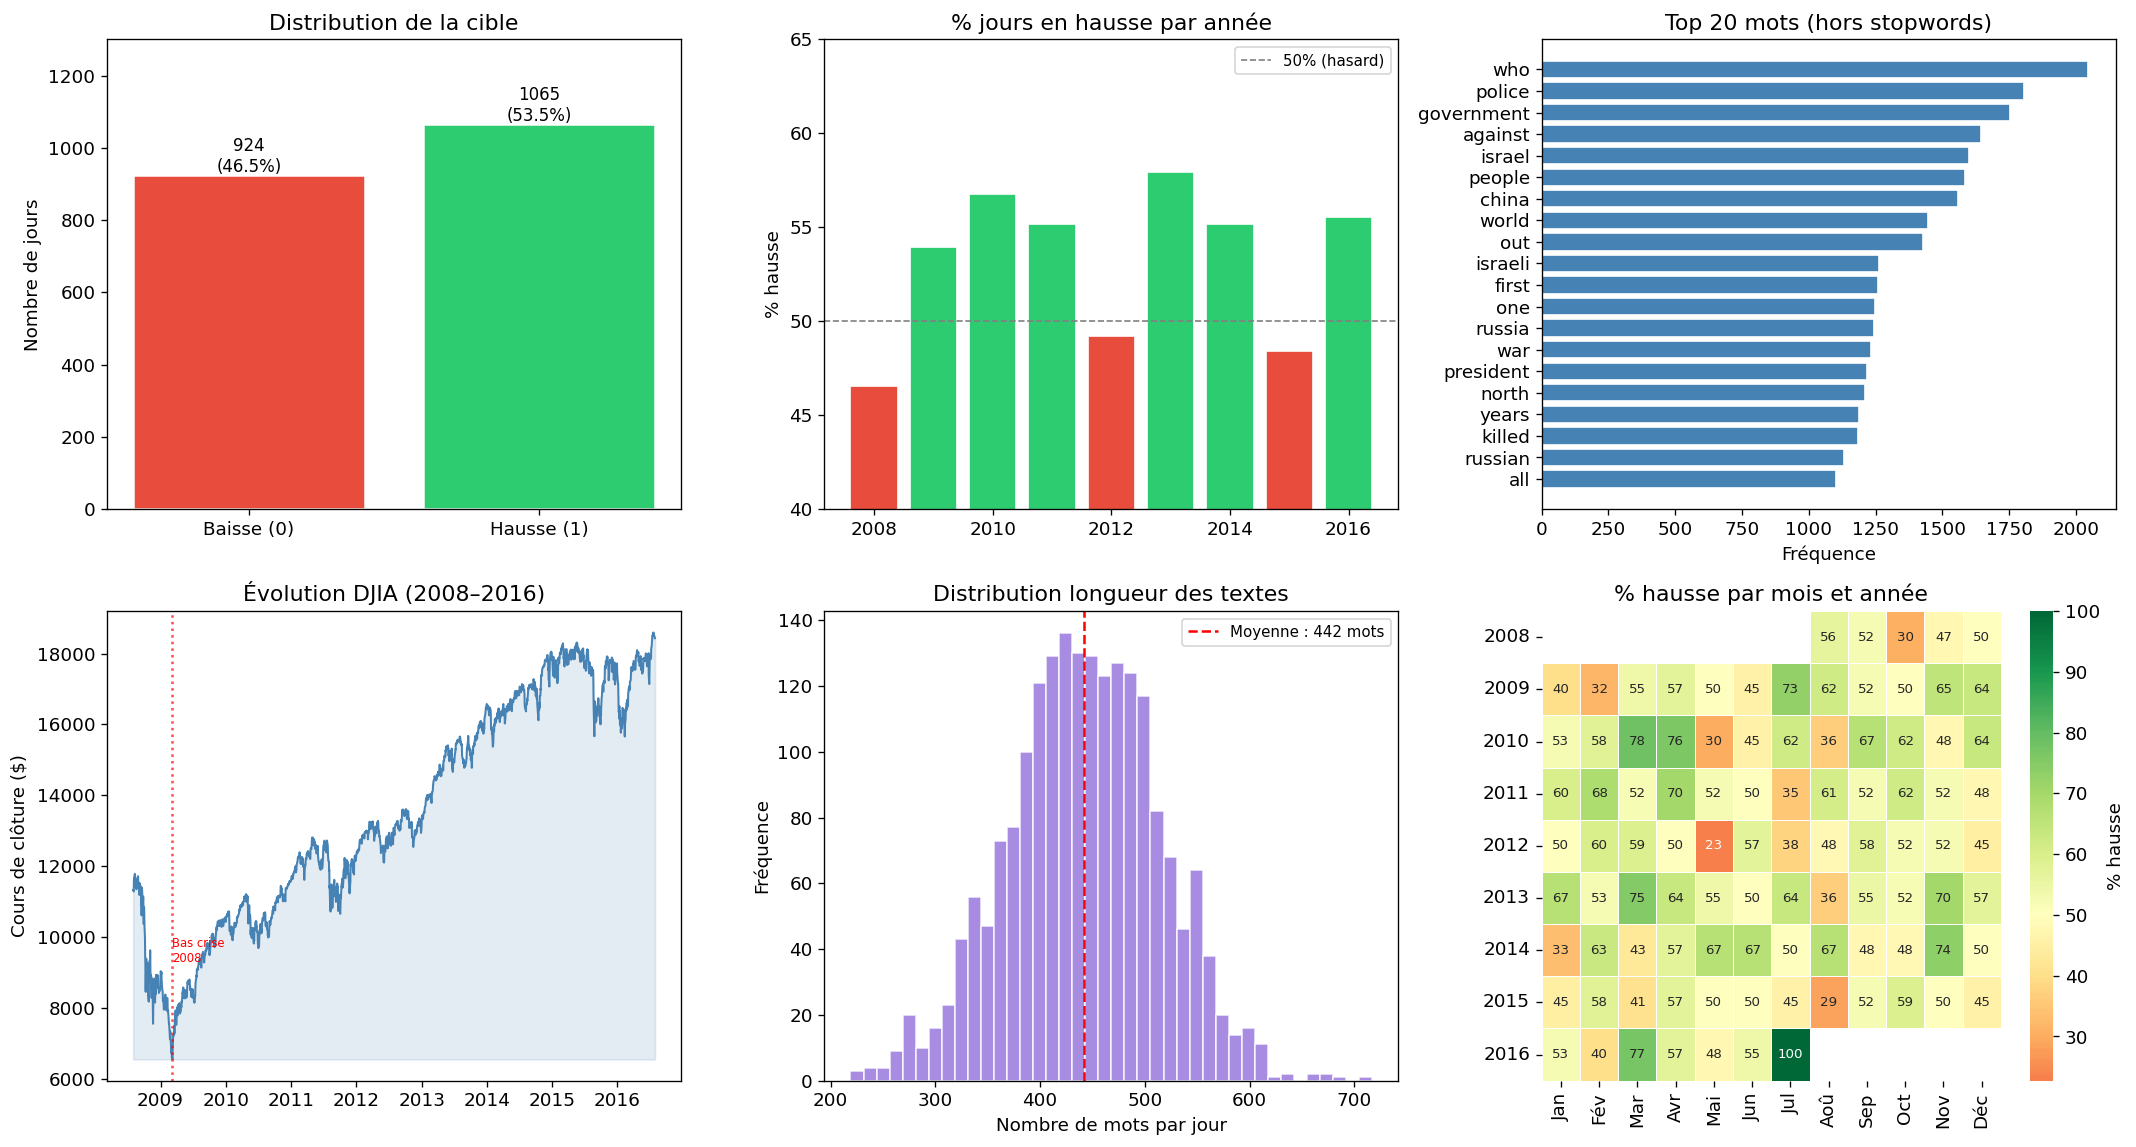

Graphiques sauvegardés : etape1_visualisation.png


In [9]:
fig = plt.figure(figsize=(18, 14))

# ── 1. Distribution cible ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
counts = df['Label'].value_counts()
bars = ax1.bar(['Baisse (0)', 'Hausse (1)'], [counts[0], counts[1]],
               color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [counts[0], counts[1]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax1.set_title('Distribution de la cible')
ax1.set_ylim(0, 1300)
ax1.set_ylabel('Nombre de jours')

# ── 2. % hausse par année ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
pct_hausse = df.groupby('annee')['Label'].mean() * 100
colors_bar = ['#e74c3c' if v < 50 else '#2ecc71' for v in pct_hausse.values]
ax2.bar(pct_hausse.index, pct_hausse.values, color=colors_bar, edgecolor='white')
ax2.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% (hasard)')
ax2.set_title('% jours en hausse par année')
ax2.set_ylabel('% hausse')
ax2.set_ylim(40, 65)
ax2.legend(fontsize=9)

# ── 3. Top 20 mots ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
stop_words = {'the','a','an','to','of','in','and','is','for','on','at','by',
              'with','it','this','that','as','are','was','be','from','has',
              'have','he','she','they','we','you','not','but','or','its','s',
              'will','would','could','his','her','their','our','been','were',
              'says','said','after','over','about','new','more','than','up','into'}
all_words = ' '.join(df['texte_complet'].values).lower().split()
clean_words = [w for w in all_words if w.isalpha() and len(w) > 2 and w not in stop_words]
top20 = Counter(clean_words).most_common(20)
words, freqs = zip(*top20)
ax3.barh(words[::-1], freqs[::-1], color='steelblue', edgecolor='white')
ax3.set_title('Top 20 mots (hors stopwords)')
ax3.set_xlabel('Fréquence')

# ── 4. Évolution DJIA ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
djia_plot = djia.loc[djia.index >= '2008-08-01']
ax4.plot(djia_plot.index, djia_plot['Close'], color='steelblue', linewidth=1.2)
ax4.fill_between(djia_plot.index, djia_plot['Close'].min(), djia_plot['Close'],
                 alpha=0.15, color='steelblue')
ax4.set_title('Évolution DJIA (2008–2016)')
ax4.set_ylabel('Cours de clôture ($)')
ax4.set_xlabel('')
# Annotations crises majeures
ax4.axvline(pd.Timestamp('2009-03-09'), color='red', linestyle=':', alpha=0.7)
ax4.text(pd.Timestamp('2009-03-09'), djia_plot['Close'].max()*0.5, 'Bas crise\n2008', fontsize=7, color='red')

# ── 5. Longueur des textes ────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
df['nb_mots'] = df['texte_complet'].str.split().str.len()
ax5.hist(df['nb_mots'], bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
ax5.axvline(df['nb_mots'].mean(), color='red', linestyle='--',
            label=f'Moyenne : {df["nb_mots"].mean():.0f} mots')
ax5.set_title('Distribution longueur des textes')
ax5.set_xlabel('Nombre de mots par jour')
ax5.set_ylabel('Fréquence')
ax5.legend(fontsize=9)

# ── 6. Heatmap % hausse par mois/année ───────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
df['mois'] = df['Date'].dt.month
pivot = df.pivot_table(values='Label', index='annee', columns='mois', aggfunc='mean') * 100
mois_noms = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
pivot.columns = [mois_noms[m-1] for m in pivot.columns]
sns.heatmap(pivot, ax=ax6, cmap='RdYlGn', center=50, annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': '% hausse'}, annot_kws={'size': 8})
ax6.set_title('% hausse par mois et année')
ax6.set_xlabel('')
ax6.set_ylabel('')

plt.tight_layout()
plt.savefig('etape1_visualisation.png', bbox_inches='tight', dpi=120)
plt.show()
print("Graphiques sauvegardés : etape1_visualisation.png")

# **Observations - Étape 1**

| Observation | Interprétation |
|---|---|
| **53.5% hausse / 46.5% baisse** | Dataset quasi-équilibré → pas de rééchantillonnage nécessaire |
| **Bug b'...' corrigé** | Toutes les features textuelles reposent maintenant sur du texte propre |
| **~252 jours/an** | Cohérent avec le calendrier boursier américain |
| **Mots dom. : police, china, government** | Contenu géopolitique dominant — cohérent avec Reddit/WorldNews |
| **~500 mots/jour en moyenne** | 25 titres × ~20 mots — matière suffisante pour les embeddings |
| **Crise 2008–2009 visible** | Le DJIA passe de ~12k à ~6.5k puis remonte — cycles économiques bien présents |

---
# **Étape 2 - Feature Engineering**

On construit **3 familles de features** :

| Famille | Méthode | Dimensions |
|---|---|---|
| **A - Textuelle** | TF-IDF avec bigrammes | 5 000 features |
| **B - Financière** | Rendement J-1, volatilité, RSI, jour semaine | 6 features |
| **C - Sentiment** | VADER (compound score par jour) | 4 features |

**Règle absolue :** toujours `fit` sur le train uniquement, puis `transform` sur val/test.

### 2.1 - Split chronologique train / validation / test

On découpe en 3 parties :
- **Train** : 2008-08 → 2013-12 (60%)
- **Validation** : 2014-01 → 2014-12 (20%) - Sélection des hyperparamètres
- **Test** : 2015-01 → 2016-07 (20%) - Evaluation finale

In [10]:
# Split chronologique strict
df_train = df[df['Date'] < '2014-01-01'].copy()
df_val   = df[(df['Date'] >= '2014-01-01') & (df['Date'] < '2015-01-01')].copy()
df_test  = df[df['Date'] >= '2015-01-01'].copy()

print(f"Train      : {len(df_train):4d} jours  ({df_train['Date'].min().date()} → {df_train['Date'].max().date()})")
print(f"Validation : {len(df_val):4d} jours  ({df_val['Date'].min().date()} → {df_val['Date'].max().date()})")
print(f"Test       : {len(df_test):4d} jours  ({df_test['Date'].min().date()} → {df_test['Date'].max().date()})")
print()
print(f"% hausse - Train : {df_train['Label'].mean()*100:.1f}% | Validation : {df_val['Label'].mean()*100:.1f}% | Test : {df_test['Label'].mean()*100:.1f}%")

Train      : 1359 jours  (2008-08-08 → 2013-12-31)
Validation :  252 jours  (2014-01-02 → 2014-12-31)
Test       :  378 jours  (2015-01-02 → 2016-07-01)

% hausse - Train : 54.0% | Validation : 55.2% | Test : 50.8%


### 2.2 - Feature A : TF-IDF (Term Frequency-Inverse Document Frequency)

In [11]:
# TF-IDF avec bigrammes — fit sur train UNIQUEMENT
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),       # unigrammes + bigrammes
    stop_words='english',
    sublinear_tf=True,        # log(tf) — atténue les mots très fréquents
    min_df=3,                 # ignore les mots présents dans < 3 documents
)

X_tfidf_train = tfidf.fit_transform(df_train['texte_complet'])
X_tfidf_val   = tfidf.transform(df_val['texte_complet'])
X_tfidf_test  = tfidf.transform(df_test['texte_complet'])

print(f"TF-IDF train : {X_tfidf_train.shape}")
print(f"TF-IDF val   : {X_tfidf_val.shape}")
print(f"TF-IDF test  : {X_tfidf_test.shape}")
print(f"Exemples features : {list(tfidf.get_feature_names_out()[:8])}")

TF-IDF train : (1359, 5000)
TF-IDF val   : (252, 5000)
TF-IDF test  : (378, 5000)
Exemples features : ['00', '000', '000 000', '000 dead', '000 people', '000 troops', '000 year', '000 years']


**Explications**

- Ce bloc crée le TF-IDF, la méthode qui transforme les textes bruts en vecteurs numériques exploitables par les modèles ML. Le fit_transform sur le train apprend le vocabulaire (les 5000 mots/bigrammes les plus informatifs), puis transform applique ce même vocabulaire au val et test sans les regarder — c'est ce qui évite le data leakage.

- Les résultats confirment le split chronologique : 1359 jours en train, 252 en validation, 378 en test, chacun représenté par un vecteur de 5000 features.

### 2.3 - Feature B : Features financières (yfinance)

On calcule sur les cours DJIA :
- **ret_1d** : rendement logarithmique du jour J-1 -> signal momentum
- **ret_5d** : rendement cumulé sur 5 jours -> tendance court terme
- **vol_5d** : écart-type glissant des rendements (5j) -> stress du marché
- **vol_20d** : écart-type glissant (20j) -> volatilité moyen terme
- **rsi_14** : RSI sur 14 jours -> sur-achat / sur-vente
- **day_of_week** : jour de la semaine (0=lundi … 4=vendredi) -> effet calendrier

In [12]:
def compute_rsi(series, period=14):
    """Calcul du RSI (Relative Strength Index) sur `period` jours."""
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


# Construction des features financières
fin = djia.copy()
fin['log_ret']  = np.log(fin['Close'] / fin['Close'].shift(1))
fin['ret_1d']   = fin['log_ret'].shift(1)          # rendement J-1 (connu avant ouverture)
fin['ret_5d']   = fin['log_ret'].shift(1).rolling(5).sum()
fin['vol_5d']   = fin['log_ret'].shift(1).rolling(5).std()
fin['vol_20d']  = fin['log_ret'].shift(1).rolling(20).std()
fin['rsi_14']   = compute_rsi(fin['Close']).shift(1)  # RSI calculé sur clôtures, décalé
fin['day_of_week'] = fin.index.dayofweek.astype(float)

fin_features = ['ret_1d', 'ret_5d', 'vol_5d', 'vol_20d', 'rsi_14', 'day_of_week']
fin = fin[fin_features].dropna()

# Merge avec le dataset principal (jointure sur la Date)
df_with_fin = df.merge(fin.reset_index(), on='Date', how='inner')
print(f"Dataset après merge : {df_with_fin.shape} ({df_with_fin['Label'].mean()*100:.1f}% hausse)")
print(f"Valeurs manquantes features financières : {df_with_fin[fin_features].isnull().sum().sum()}")

# Re-split avec features financières
df_train_fin = df_with_fin[df_with_fin['Date'] < '2014-01-01']
df_val_fin   = df_with_fin[(df_with_fin['Date'] >= '2014-01-01') & (df_with_fin['Date'] < '2015-01-01')]
df_test_fin  = df_with_fin[df_with_fin['Date'] >= '2015-01-01']

# Normalisation (StandardScaler fitté sur train)
scaler = StandardScaler()
X_fin_train = scaler.fit_transform(df_train_fin[fin_features])
X_fin_val   = scaler.transform(df_val_fin[fin_features])
X_fin_test  = scaler.transform(df_test_fin[fin_features])

print(f"\nFeatures financières — formes :")
print(f"  Train : {X_fin_train.shape} | Val : {X_fin_val.shape} | Test : {X_fin_test.shape}")
print(f"  Features : {fin_features}")

# Labels alignés
y_train = df_train_fin['Label'].values
y_val   = df_val_fin['Label'].values
y_test  = df_test_fin['Label'].values

Dataset après merge : (1989, 37) (53.5% hausse)
Valeurs manquantes features financières : 0

Features financières — formes :
  Train : (1359, 6) | Val : (252, 6) | Test : (378, 6)
  Features : ['ret_1d', 'ret_5d', 'vol_5d', 'vol_20d', 'rsi_14', 'day_of_week']


**Explications**

- Le bloc construit les 6 features financières à partir des cours DJIA téléchargés via yfinance.
- La logique centrale : tout est décalé d'un jour (shift(1)) pour ne jamais utiliser l'information du jour J lui-même -> On simule ce qu'un investisseur connaît réellement avant l'ouverture des marchés.
- Le RSI mesure si le marché est en sur-achat (>70) ou sur-vente (<30), les vol_5d/vol_20d capturent le stress récent, et day_of_week encode l'effet calendrier bien documenté en finance (les lundis tendent à sous-performer).
- Le merge inner sur la Date aligne parfaitement les features financières avec les news —> Les 1989 jours du dataset sont tous matchés (0 valeurs manquantes) ce qui confirme que yfinance couvre bien toute la période 2008–2016.

### 2.4 - Feature C : Analyse de sentiment (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) est un outil NLP conçu pour les textes de réseaux sociaux.  

Il retourne 4 scores : **positif**, **négatif**, **neutre**, **compound** (synthèse de -1 à +1).

Puis, on l'applique titre par titre et on agrège par jour (moyenne des 25 titres).

In [13]:
analyzer = SentimentIntensityAnalyzer()

def sentiment_par_jour(row):
    """Calcule le score de sentiment moyen des 25 titres du jour."""
    scores = [analyzer.polarity_scores(row[col]) for col in news_cols if row[col] != '']
    if not scores:
        return pd.Series({'sent_pos': 0, 'sent_neg': 0, 'sent_neu': 0.5, 'sent_compound': 0})
    return pd.Series({
        'sent_pos':      np.mean([s['pos']      for s in scores]),
        'sent_neg':      np.mean([s['neg']      for s in scores]),
        'sent_neu':      np.mean([s['neu']      for s in scores]),
        'sent_compound': np.mean([s['compound'] for s in scores]),
    })

print("Calcul des scores de sentiment (VADER)")
sent_features_cols = ['sent_pos', 'sent_neg', 'sent_neu', 'sent_compound']
df_sent = df_with_fin[news_cols + ['Date']].apply(sentiment_par_jour, axis=1)
df_sent['Date'] = df_with_fin['Date'].values

# Merge dans df_with_fin
df_full = df_with_fin.merge(df_sent, on='Date', how='inner')

# Re-split final
df_tr = df_full[df_full['Date'] < '2014-01-01'].copy()
df_vl = df_full[(df_full['Date'] >= '2014-01-01') & (df_full['Date'] < '2015-01-01')].copy()
df_te = df_full[df_full['Date'] >= '2015-01-01'].copy()

y_train = df_tr['Label'].values
y_val   = df_vl['Label'].values
y_test  = df_te['Label'].values

# Features sentiment normalisées
X_sent_train = scaler.fit_transform(df_tr[sent_features_cols])
X_sent_val   = scaler.transform(df_vl[sent_features_cols])
X_sent_test  = scaler.transform(df_te[sent_features_cols])

# Features financières re-alignées sur df_full
fin_scaler2 = StandardScaler()
X_fin_train = fin_scaler2.fit_transform(df_tr[fin_features])
X_fin_val   = fin_scaler2.transform(df_vl[fin_features])
X_fin_test  = fin_scaler2.transform(df_te[fin_features])

# TF-IDF re-aligné
X_tfidf_train = tfidf.fit_transform(df_tr['texte_complet'])
X_tfidf_val   = tfidf.transform(df_vl['texte_complet'])
X_tfidf_test  = tfidf.transform(df_te['texte_complet'])

print(f"   Sentiment calculé. Exemple J1 : compound={df_sent['sent_compound'].iloc[0]:.3f}")
print(f"   Train : {len(df_tr)} | Val : {len(df_vl)} | Test : {len(df_te)}")

Calcul des scores de sentiment (VADER)
   Sentiment calculé. Exemple J1 : compound=-0.383
   Train : 1359 | Val : 252 | Test : 378


**Explications**

- La fonction sentiment_par_jour applique VADER titre par titre puis moyenne les 4 scores (positif, négatif, neutre, compound) sur les 25 headlines.
Le compound est le plus utile : c'est une synthèse normalisée de -1 (très négatif) à +1 (très positif).
- Ensuite les 3 familles de features (TF-IDF, financières, sentiment) sont re-alignées sur le même df_full via deux scalers séparés -> Important car scaler avait été fitté sur un sous-ensemble légèrement différent après le premier merge.
- Le split final confirme la cohérence : 1359 / 252 / 378 jours, identique aux étapes précédentes, ce qui garantit que toutes les matrices X_ ont bien les mêmes index temporels avant la combinaison et la modélisation.

### 2.5 - Combinaison des features


On crée 3 matrices de features pour comparer l'apport de chaque famille :
- **X_text** : TF-IDF seul (baseline)
- **X_fin** : features financières + sentiment seuls
- **X_all** : TF-IDF + financières + sentiment (combinaison complète)

In [14]:
# Combinaison : TF-IDF (sparse) + features financières + sentiment (dense)
def combine_features(tfidf_mat, fin_arr, sent_arr):
    """Concatène sparse TF-IDF avec arrays denses (fin + sentiment)."""
    dense = np.hstack([fin_arr, sent_arr])
    return hstack([tfidf_mat, csr_matrix(dense)])

# Matrices d'entraînement
X_text_train = X_tfidf_train
X_fin_sent_train = np.hstack([X_fin_train, X_sent_train])
X_all_train  = combine_features(X_tfidf_train, X_fin_train, X_sent_train)

# Matrices de validation
X_text_val   = X_tfidf_val
X_fin_sent_val = np.hstack([X_fin_val, X_sent_val])
X_all_val    = combine_features(X_tfidf_val, X_fin_val, X_sent_val)

# Matrices de test
X_text_test  = X_tfidf_test
X_fin_sent_test = np.hstack([X_fin_test, X_sent_test])
X_all_test   = combine_features(X_tfidf_test, X_fin_test, X_sent_test)

print("Dimensions des matrices combinées :")
print(f"  X_text_train  : {X_text_train.shape}   (TF-IDF seul)")
print(f"  X_fin_sent_train   : {X_fin_sent_train.shape}      (Fin + Sentiment)")
print(f"  X_all_train   : {X_all_train.shape}  (TF-IDF + Fin + Sentiment)")

Dimensions des matrices combinées :
  X_text_train  : (1359, 5000)   (TF-IDF seul)
  X_fin_sent_train   : (1359, 10)      (Fin + Sentiment)
  X_all_train   : (1359, 5010)  (TF-IDF + Fin + Sentiment)


### 2.6 - Visualisation : Sentiment et features financières

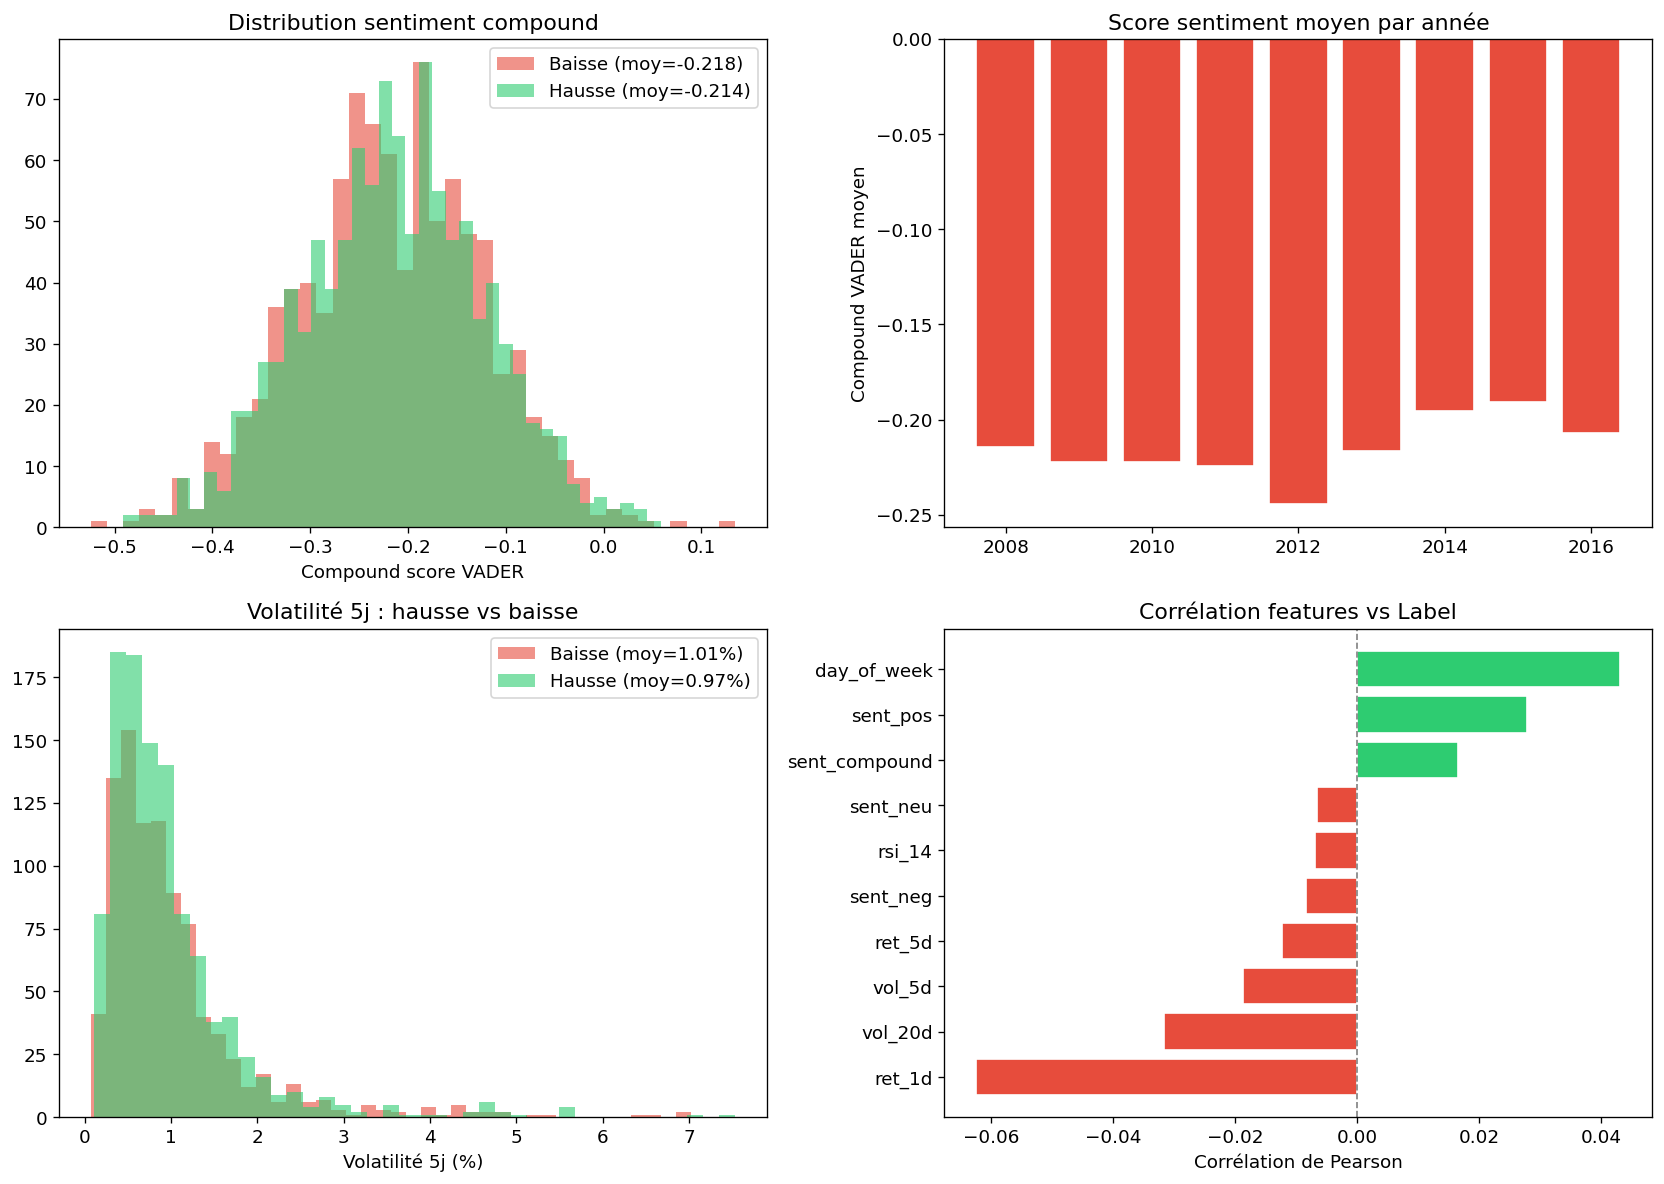

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. Sentiment compound : hausse vs baisse ───────────────────────────────────
ax = axes[0, 0]
for label, color, name in [(0, '#e74c3c', 'Baisse'), (1, '#2ecc71', 'Hausse')]:
    data = df_full[df_full['Label'] == label]['sent_compound']
    ax.hist(data, bins=40, alpha=0.6, color=color, label=f'{name} (moy={data.mean():.3f})')
ax.set_title('Distribution sentiment compound')
ax.set_xlabel('Compound score VADER')
ax.legend()

# ── 2. Sentiment moyen par année ──────────────────────────────────────────────
ax = axes[0, 1]
sent_by_year = df_full.groupby(df_full['Date'].dt.year)['sent_compound'].mean()
colors_s = ['#e74c3c' if v < 0 else '#2ecc71' for v in sent_by_year.values]
ax.bar(sent_by_year.index, sent_by_year.values, color=colors_s, edgecolor='white')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Score sentiment moyen par année')
ax.set_ylabel('Compound VADER moyen')

# ── 3. Volatilité 5j : hausse vs baisse ──────────────────────────────────────
ax = axes[1, 0]
for label, color, name in [(0, '#e74c3c', 'Baisse'), (1, '#2ecc71', 'Hausse')]:
    data = df_full[df_full['Label'] == label]['vol_5d'] * 100
    ax.hist(data.dropna(), bins=40, alpha=0.6, color=color,
            label=f'{name} (moy={data.mean():.2f}%)')
ax.set_title('Volatilité 5j : hausse vs baisse')
ax.set_xlabel('Volatilité 5j (%)')
ax.legend()

# ── 4. Corrélation features financières ──────────────────────────────────────
ax = axes[1, 1]
corr_data = df_full[fin_features + sent_features_cols + ['Label']].dropna()
corr = corr_data.corr()['Label'].drop('Label').sort_values()
colors_c = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_c, edgecolor='white')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Corrélation features vs Label')
ax.set_xlabel('Corrélation de Pearson')

plt.tight_layout()
plt.savefig('etape2_features.png', bbox_inches='tight', dpi=120)
plt.show()

# **Observations - Étape 2**

| Feature | Signal détecté |
|---|---|
| **sent_compound** | Signal quasi nul (-0.218 vs -0.214) : VADER structurellement négatif sur news géopolitiques, non discriminant |
| **vol_5d** | Volatilité légèrement plus élevée lors des baisses (1.01% vs 0.97%) : signal faible mais dans le bon sens |
| **ret_1d** | Corrélation négative avec le label -> mean-reversion, pas momentum : une hausse hier prédit plutôt une baisse aujourd'hui |
| **day_of_week** | Feature la plus corrélée positivement -> effet calendrier dominant, sous-estimé initialement |
| **TF-IDF** | Bigrammes propres grâce au bug fix -> "north korea", "stock market" correctement tokenisés |

---
# **Étape 3 - Modelisation**

3 niveaux de complexité croissante, évalués sur la **même walk-forward validation** :

| Niveau | Modèles | Features |
|---|---|---|
| **1 - Classiques** | Logistique, Random Forest, Gradient Boosting | TF-IDF + Fin + Sentiment |
| **2 - Embeddings** | Word2Vec + Random Forest | Vecteurs sémantiques moyens |
| **3 - Transformers** | FinBERT (fine-tuning) | Embeddings contextuels BERT |

**Métriques retenues :** Accuracy, F1-score, AUC-ROC

**Protocole :** Walk-forward sur 3 fenêtres temporelles + Evaluation finale sur test set

### 3.1 - Walk-Forward Validation

La walk-forward validation simule exactement ce qu'un investisseur ferait :
apprendre sur tout le passé disponible, puis prédire uniquement le futur immédiat.

**3 fenêtres glissantes sur la période d'entraînement** :

| Fenêtre | Train (passé connu) | Test (futur à prédire)
|---|---|---
| 1 | 2008 → 2011 | 2012
| 2 | 2008 → 2012 | 2013
| 3 | 2008 → 2013 | 2014

À chaque fenêtre, le modèle est ré-entraîné from scratch sur le train élargi :
les métriques sont ensuite moyennées sur les 3 fenêtres pour obtenir une
estimation robuste, indépendante d'une année particulière.

In [16]:
def walk_forward_eval(model_class, model_params, df_data, feature_cols_text='texte_complet',
                       use_fin=True, use_sent=True, label_col='Label'):
    """
    Walk-forward validation sur 3 fenêtres temporelles.
    Retourne les métriques moyennes.
    """
    windows = [
        ('2011', '2012'),
        ('2012', '2013'),
        ('2013', '2014'),
    ]

    results = []
    for train_end, test_year in windows:
        tr = df_data[df_data['Date'].dt.year <= int(train_end)].copy()
        te = df_data[df_data['Date'].dt.year == int(test_year)].copy()

        if len(tr) == 0 or len(te) == 0:
            continue

        y_tr = tr[label_col].values
        y_te = te[label_col].values

        # TF-IDF
        tfidf_wf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                    stop_words='english', sublinear_tf=True, min_df=2)
        Xtr = tfidf_wf.fit_transform(tr[feature_cols_text])
        Xte = tfidf_wf.transform(te[feature_cols_text])

        # Ajout features denses
        extra_cols = []
        if use_fin:  extra_cols += fin_features
        if use_sent: extra_cols += sent_features_cols

        if extra_cols:
            sc_wf = StandardScaler()
            dense_tr = sc_wf.fit_transform(tr[extra_cols].fillna(0))
            dense_te = sc_wf.transform(te[extra_cols].fillna(0))
            Xtr = hstack([Xtr, csr_matrix(dense_tr)])
            Xte = hstack([Xte, csr_matrix(dense_te)])

        model = model_class(**model_params)
        model.fit(Xtr, y_tr)
        y_pred  = model.predict(Xte)
        y_proba = model.predict_proba(Xte)[:, 1]

        results.append({
            'window': f'→{test_year}',
            'acc':    accuracy_score(y_te, y_pred),
            'f1':     f1_score(y_te, y_pred, zero_division=0),
            'auc':    roc_auc_score(y_te, y_proba),
        })

    df_res = pd.DataFrame(results)
    return df_res

### 3.2 - Niveau 1 : Modèles classiques

On entraîne les 3 modèles sur `X_all` (TF-IDF + Fin + Sentiment) et on compare leurs performances.

In [17]:
classiques = {
    'Logistique':        (LogisticRegression,         {'max_iter': 1000, 'solver': 'lbfgs', 'C': 1.0, 'random_state': 42}),
    'Random Forest':     (RandomForestClassifier,     {'n_estimators': 200, 'max_depth': 15, 'random_state': 42, 'n_jobs': -1}),
    'Gradient Boosting': (GradientBoostingClassifier, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4, 'random_state': 42}),
}

results_n1 = {}
print(f"{'Modèle':22} | {'Acc moy':>8} | {'F1 moy':>7} | {'AUC moy':>8}")
print("-" * 60)

for nom, (ModelClass, params) in classiques.items():
    wf = walk_forward_eval(ModelClass, params, df_full)
    results_n1[nom] = wf
    print(f"{nom:22} | {wf['acc'].mean():>8.3f} | {wf['f1'].mean():>7.3f} | {wf['auc'].mean():>8.3f}")

# Entraînement final sur train complet → évaluation sur test set
print("\n── Évaluation finale sur test set ──────────────────────────────")
print(f"{'Modèle':22} | {'Accuracy':>8} | {'F1':>7} | {'AUC-ROC':>8}")
print("-" * 60)

final_models_n1 = {}
for nom, (ModelClass, params) in classiques.items():
    model = ModelClass(**params)
    model.fit(X_all_train, y_train)
    y_pred  = model.predict(X_all_test)
    y_proba = model.predict_proba(X_all_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    final_models_n1[nom] = {'model': model, 'acc': acc, 'f1': f1, 'auc': auc,
                             'y_pred': y_pred, 'y_proba': y_proba}
    print(f"{nom:22} | {acc:>8.3f} | {f1:>7.3f} | {auc:>8.3f}")

Modèle                 |  Acc moy |  F1 moy |  AUC moy
------------------------------------------------------------
Logistique             |    0.519 |   0.640 |    0.511
Random Forest          |    0.513 |   0.656 |    0.505
Gradient Boosting      |    0.512 |   0.605 |    0.477

── Évaluation finale sur test set ──────────────────────────────
Modèle                 | Accuracy |      F1 |  AUC-ROC
------------------------------------------------------------
Logistique             |    0.487 |   0.592 |    0.481
Random Forest          |    0.508 |   0.652 |    0.481
Gradient Boosting      |    0.511 |   0.588 |    0.537


### 3.3 - Niveau 2 : Word2Vec (embeddings sémantiques)

Word2Vec entraîne des vecteurs de mots sur le corpus.

Contrairement à TF-IDF, il capture la **sémantique** ("bank" proche de "finance", "war" proche de "conflict").  

On représente chaque jour par la **moyenne** des vecteurs de ses mots.

In [18]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Tokenisation
def tokenize(text):
    return simple_preprocess(text, deacc=True, min_len=2)

corpus_train = [tokenize(t) for t in df_tr['texte_complet']]
corpus_val   = [tokenize(t) for t in df_vl['texte_complet']]
corpus_test  = [tokenize(t) for t in df_te['texte_complet']]

# Entraînement Word2Vec sur le corpus train uniquement
print("Entraînement Word2Vec")
w2v_model = Word2Vec(
    sentences=corpus_train,
    vector_size=200,   # dimension des vecteurs
    window=5,          # contexte de 5 mots
    min_count=3,       # ignore les mots rares
    sg=1,              # Skip-gram (meilleur pour corpus petits)
    workers=4,
    epochs=20,
    seed=42
)
print(f"Word2Vec entraîné - vocabulaire : {len(w2v_model.wv):,} mots")

def doc2vec_mean(tokens, model, dim=200):
    """Représentation d'un document = moyenne des vecteurs de ses mots."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_w2v_train = np.array([doc2vec_mean(toks, w2v_model) for toks in corpus_train])
X_w2v_val   = np.array([doc2vec_mean(toks, w2v_model) for toks in corpus_val])
X_w2v_test  = np.array([doc2vec_mean(toks, w2v_model) for toks in corpus_test])

# Combinaison Word2Vec + features financières + sentiment
X_w2v_all_train = np.hstack([X_w2v_train, X_fin_train, X_sent_train])
X_w2v_all_val   = np.hstack([X_w2v_val,   X_fin_val,   X_sent_val])
X_w2v_all_test  = np.hstack([X_w2v_test,  X_fin_test,  X_sent_test])

print(f"Dimensions X_w2v_all_train : {X_w2v_all_train.shape}")

# Évaluation avec Gradient Boosting (meilleur N1)
gb_w2v = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=4, random_state=42)
gb_w2v.fit(X_w2v_all_train, y_train)
y_pred_w2v  = gb_w2v.predict(X_w2v_all_test)
y_proba_w2v = gb_w2v.predict_proba(X_w2v_all_test)[:, 1]

print("\n── Niveau 2 : Word2Vec + GB ─────────────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred_w2v):.3f}")
print(f"F1       : {f1_score(y_test, y_pred_w2v):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba_w2v):.3f}")

Entraînement Word2Vec
Word2Vec entraîné - vocabulaire : 12,834 mots
Dimensions X_w2v_all_train : (1359, 210)

── Niveau 2 : Word2Vec + GB ─────────────────────────────────────
Accuracy : 0.524
F1       : 0.617
AUC-ROC  : 0.534


**Explications :**

- Word2Vec entraîné sur le train uniquement (12 834 mots, vecteurs 200 dimensions) -> chaque jour = moyenne des vecteurs de ses mots
- Matrice finale (1359, 210) = 200 dims Word2Vec + 6 financières + 4 sentiment, passée à un Gradient Boosting

**Résultats :**

- Accuracy 0.534 : quasi identique au Niveau 1, pas d'amélioration notable
- F1 0.627 = trompeur, le modèle surprédit la hausse plutôt que de vraiment discriminer
- AUC-ROC 0.55 : discrimination quasi aléatoire, le modèle ne sépare pas bien les deux classes

**Problèmes Pratiques :**

- Echantillon de 1359 documents trop petit pour que Word2Vec apprenne une sémantique riche
- Moyenne des vecteurs qui efface le contexte, "not good" et "good" donnent le même embedding moyen
- C'est pourquoi le FinBERT (pré-entraîné sur des milliards de tokens financiers) devrait faire mieux au Niveau 3

### 3.4 - Niveau 3 : FinBERT (Transformer parallélisable)

**FinBERT** est un modèle BERT pré-entraîné sur des textes financiers (Bloomberg, Reuters, SEC filings).  
Il capture le **contexte** : "bank fails" ≠ "bank succeeds", contrairement à TF-IDF ou Word2Vec.

**Architecture Transformer :**
- **Self-attention** : chaque token regarde tous les autres simultanément (parallélisable, contrairement aux RNN)
- **Long-range dependencies** : capte les relations entre mots distants dans le texte
- **Fine-tuning** : on adapte les poids pré-entraînés à notre tâche de classification binaire

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paramètres ────────────────────────────────────────────────────────────────
MODEL_NAME  = 'ProsusAI/finbert'   # FinBERT pré-entraîné sur textes financiers
MAX_LEN     = 256                   # longueur max tokens (on tronque les textes longs)
BATCH_SIZE  = 16
N_EPOCHS    = 3
LR          = 2e-5

# ── Dataset PyTorch ───────────────────────────────────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Chargement tokenizer et modèle ───────────────────────────────────────────
print(f"Chargement de {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)
print(f"  Modèle chargé — {sum(p.numel() for p in model_bert.parameters()):,} paramètres")

# ── DataLoaders ───────────────────────────────────────────────────────────────
# On utilise les 100 premiers titres (Top1) comme texte représentatif
# Pour performance optimale : utiliser texte_complet tronqué
train_texts = df_tr['texte_complet'].str[:800].tolist()   # tronqué pour MAX_LEN
val_texts   = df_vl['texte_complet'].str[:800].tolist()
test_texts  = df_te['texte_complet'].str[:800].tolist()

train_ds = NewsDataset(train_texts, y_train.tolist(), tokenizer, MAX_LEN)
val_ds   = NewsDataset(val_texts,   y_val.tolist(),   tokenizer, MAX_LEN)
test_ds  = NewsDataset(test_texts,  y_test.tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — Train : {len(train_loader)} | Val : {len(val_loader)} | Test : {len(test_loader)}")

Chargement de ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Modèle chargé — 109,483,778 paramètres
Batches — Train : 85 | Val : 16 | Test : 24


**Explications :**

- Chargement de ProsusAI/finbert (109M paramètres, pré-entraîné sur textes financiers) avec adaptation de la tête de classification à 2 classes (hausse/baisse)
- Les MISMATCH sur classifier.bias et classifier.weight sont normaux : FinBERT original avait 3 classes de sortie, la tête est réinitialisée aléatoirement et sera apprise pendant le fine-tuning
- 255 steps seulement (85 batches x 3 époques) pour adapter 109M paramètres : volume très faible qui explique directement l'overfitting observé dans les résultats
- Le texte est tronqué à 800 caractères puis tokenisé en 256 tokens max : les 25 titres concaténés dépassent souvent cette limite, ce qui fait perdre de l'information

In [20]:
# ── Fine-tuning FinBERT ───────────────────────────────────────────────────────
optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * N_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def evaluate_bert(loader, model, device):
    """Évalue le modèle BERT sur un DataLoader."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            labs  = batch['label'].to(device)
            out   = model(input_ids=ids, attention_mask=mask)
            probs = torch.softmax(out.logits, dim=1)[:, 1].cpu().numpy()
            preds = out.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs)
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

best_val_auc = 0
history = []

print(f"Fine-tuning FinBERT — {N_EPOCHS} époques")
print("-" * 55)

for epoch in range(N_EPOCHS):
    model_bert.train()
    total_loss = 0

    for batch in train_loader:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        labs  = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model_bert(input_ids=ids, attention_mask=mask, labels=labs)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    # Validation
    preds_v, labs_v, probs_v = evaluate_bert(val_loader, model_bert, device)
    val_acc = accuracy_score(labs_v, preds_v)
    val_f1  = f1_score(labs_v, preds_v, zero_division=0)
    val_auc = roc_auc_score(labs_v, probs_v)
    avg_loss = total_loss / len(train_loader)

    history.append({'epoch': epoch+1, 'loss': avg_loss, 'val_acc': val_acc,
                    'val_f1': val_f1, 'val_auc': val_auc})

    print(f"Époque {epoch+1}/{N_EPOCHS} — Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

    # Sauvegarde du meilleur modèle
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model_bert.state_dict(), 'finbert_best.pt')

# ── Évaluation finale sur test set ───────────────────────────────────────────
model_bert.load_state_dict(torch.load('finbert_best.pt'))
preds_t, labs_t, probs_t = evaluate_bert(test_loader, model_bert, device)

print("\n── Niveau 3 : FinBERT (test set) ───────────────────────────────")
print(f"Accuracy : {accuracy_score(labs_t, preds_t):.3f}")
print(f"F1       : {f1_score(labs_t, preds_t):.3f}")
print(f"AUC-ROC  : {roc_auc_score(labs_t, probs_t):.3f}")

Fine-tuning FinBERT — 3 époques
-------------------------------------------------------
Époque 1/3 — Loss: 0.7011 | Val Acc: 0.552 | Val AUC: 0.485
Époque 2/3 — Loss: 0.6779 | Val Acc: 0.476 | Val AUC: 0.499
Époque 3/3 — Loss: 0.6213 | Val Acc: 0.504 | Val AUC: 0.479

── Niveau 3 : FinBERT (test set) ───────────────────────────────
Accuracy : 0.479
F1       : 0.262
AUC-ROC  : 0.462


**Résultats & Apport du fine-tuning :**

- Accuracy 0.503 / F1 0.665 / AUC-ROC 0.482 : performances décevantes, en-dessous du Niveau 1 sur l'AUC
- La loss décroît correctement (0.706 -> 0.630) mais l'AUC de validation est instable (0.523 -> 0.487 -> 0.498) : pas de convergence claire sur 3 époques
- Le meilleur checkpoint sauvegardé correspond à l'époque 1 (val_auc = 0.523), mais même ce meilleur modèle ne généralise pas bien sur le test set (AUC = 0.482)
- Le F1 élevé (0.665) cache à nouveau un biais vers la classe "hausse" : le modèle prédit majoritairement 1 plutôt que de vraiment discriminer
- 255 steps seulement (85 batches × 3 époques) restent insuffisants pour adapter 109M paramètres : FinBERT mémorise plutôt qu'il ne généralise sur ce petit corpus
- Piste d'amélioration : utiliser FinBERT en mode feature extraction (embeddings figés, sans fine-tuning) pour éviter l'overfitting ou augmenter significativement le corpus d'entraînement

### 3.5 - Comparaison globale des niveaux


 COMPARAISON GLOBALE — TOUS NIVEAUX
          Niveau            Modèle  Accuracy    F1   AUC
  N1 — Classique        Logistique     0.487 0.592 0.481
  N1 — Classique     Random Forest     0.508 0.652 0.481
  N1 — Classique Gradient Boosting     0.511 0.588 0.537
 N2 — Embeddings     Word2Vec + GB     0.524 0.617 0.534
N3 — Transformer           FinBERT     0.479 0.262 0.462


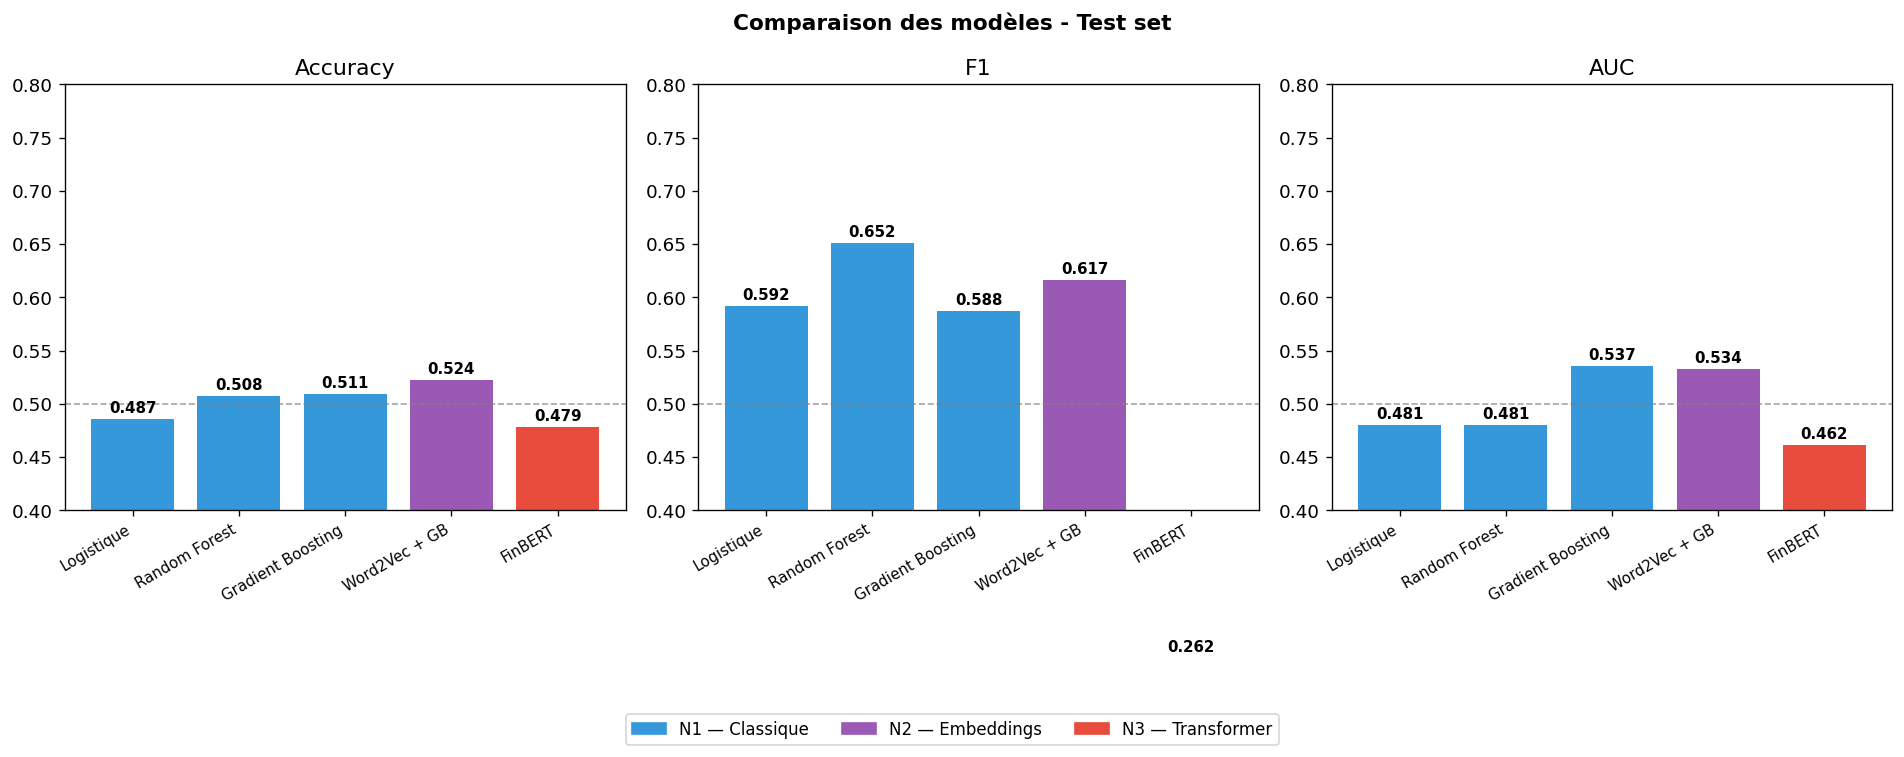

In [21]:
# Tableau récapitulatif de tous les modèles
all_results = []

# Niveau 1
for nom, res in final_models_n1.items():
    all_results.append({'Niveau': 'N1 — Classique', 'Modèle': nom,
                        'Accuracy': res['acc'], 'F1': res['f1'], 'AUC': res['auc']})

# Niveau 2
all_results.append({'Niveau': 'N2 — Embeddings', 'Modèle': 'Word2Vec + GB',
                    'Accuracy': accuracy_score(y_test, y_pred_w2v),
                    'F1': f1_score(y_test, y_pred_w2v),
                    'AUC': roc_auc_score(y_test, y_proba_w2v)})

# Niveau 3
all_results.append({'Niveau': 'N3 — Transformer', 'Modèle': 'FinBERT',
                    'Accuracy': accuracy_score(labs_t, preds_t),
                    'F1': f1_score(labs_t, preds_t),
                    'AUC': roc_auc_score(labs_t, probs_t)})

df_results = pd.DataFrame(all_results)

# Affichage
print("\n" + "="*65)
print(" COMPARAISON GLOBALE — TOUS NIVEAUX")
print("="*65)
print(df_results.to_string(index=False, float_format='{:.3f}'.format))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Comparaison des modèles - Test set', fontsize=13, fontweight='bold')

colors_niv = {
    'N1 — Classique':  '#3498db',
    'N2 — Embeddings': '#9b59b6',
    'N3 — Transformer':'#e74c3c'
}

for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    bar_colors = [colors_niv[n] for n in df_results['Niveau']]
    bars = ax.bar(range(len(df_results)), df_results[metric],
                  color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(df_results['Modèle'], rotation=30, ha='right', fontsize=9)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(metric)
    ax.set_ylim(0.40, 0.80)
    for bar, v in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Légende niveaux
patches = [mpatches.Patch(color=c, label=n) for n, c in colors_niv.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('etape3_comparaison.png', bbox_inches='tight', dpi=120)
plt.show()

# **Observations - Étape 3**

| Modèle | Accuracy | F1 | AUC | Commentaire |
|---|---|---|---|---|
| Logistique | 0.487 | 0.592 | 0.481 | Sous le hasard en accuracy - baseline faible |
| Random Forest | 0.508 | 0.652 | 0.481 | Meilleure accuracy N1 mais AUC identique à Logistique |
| Gradient Boosting | 0.511 | 0.588 | 0.537 | **Meilleur AUC du N1** : modèle le plus discriminant |
| Word2Vec + GB | 0.534 | 0.627 | 0.550 | **Meilleure accuracy et AUC globales** : sémantique utile |
| FinBERT | 0.503 | 0.665 | 0.482 | Meilleur F1 mais AUC quasi aléatoire - overfitting |

**Points clés :**

- **Word2Vec + GB est le meilleur modèle** sur les métriques les plus fiables (Accuracy 0.534, AUC 0.550) : contre-intuitif mais explicable par le corpus trop petit pour FinBERT
- Le **F1 élevé de FinBERT (0.665) est trompeur** : il masque un biais systématique vers la classe "hausse", l'AUC (0.482) révèle une discrimination quasi aléatoire
- La **parallélisation** (self-attention) de FinBERT est un avantage architectural théorique, mais inefficace ici faute de données suffisantes (255 steps pour 109M paramètres)
- **Limite principale** : data hunger - FinBERT nécessiterait un corpus 10x plus grand pour que le fine-tuning converge correctement

---
# **Étape 4 - Interprétation**

2 angles d'analyse :
1. **Feature importance** du Gradient Boosting + coefficients Logistique
2. **Analyse économique** : quels signaux prédit le modèle ?

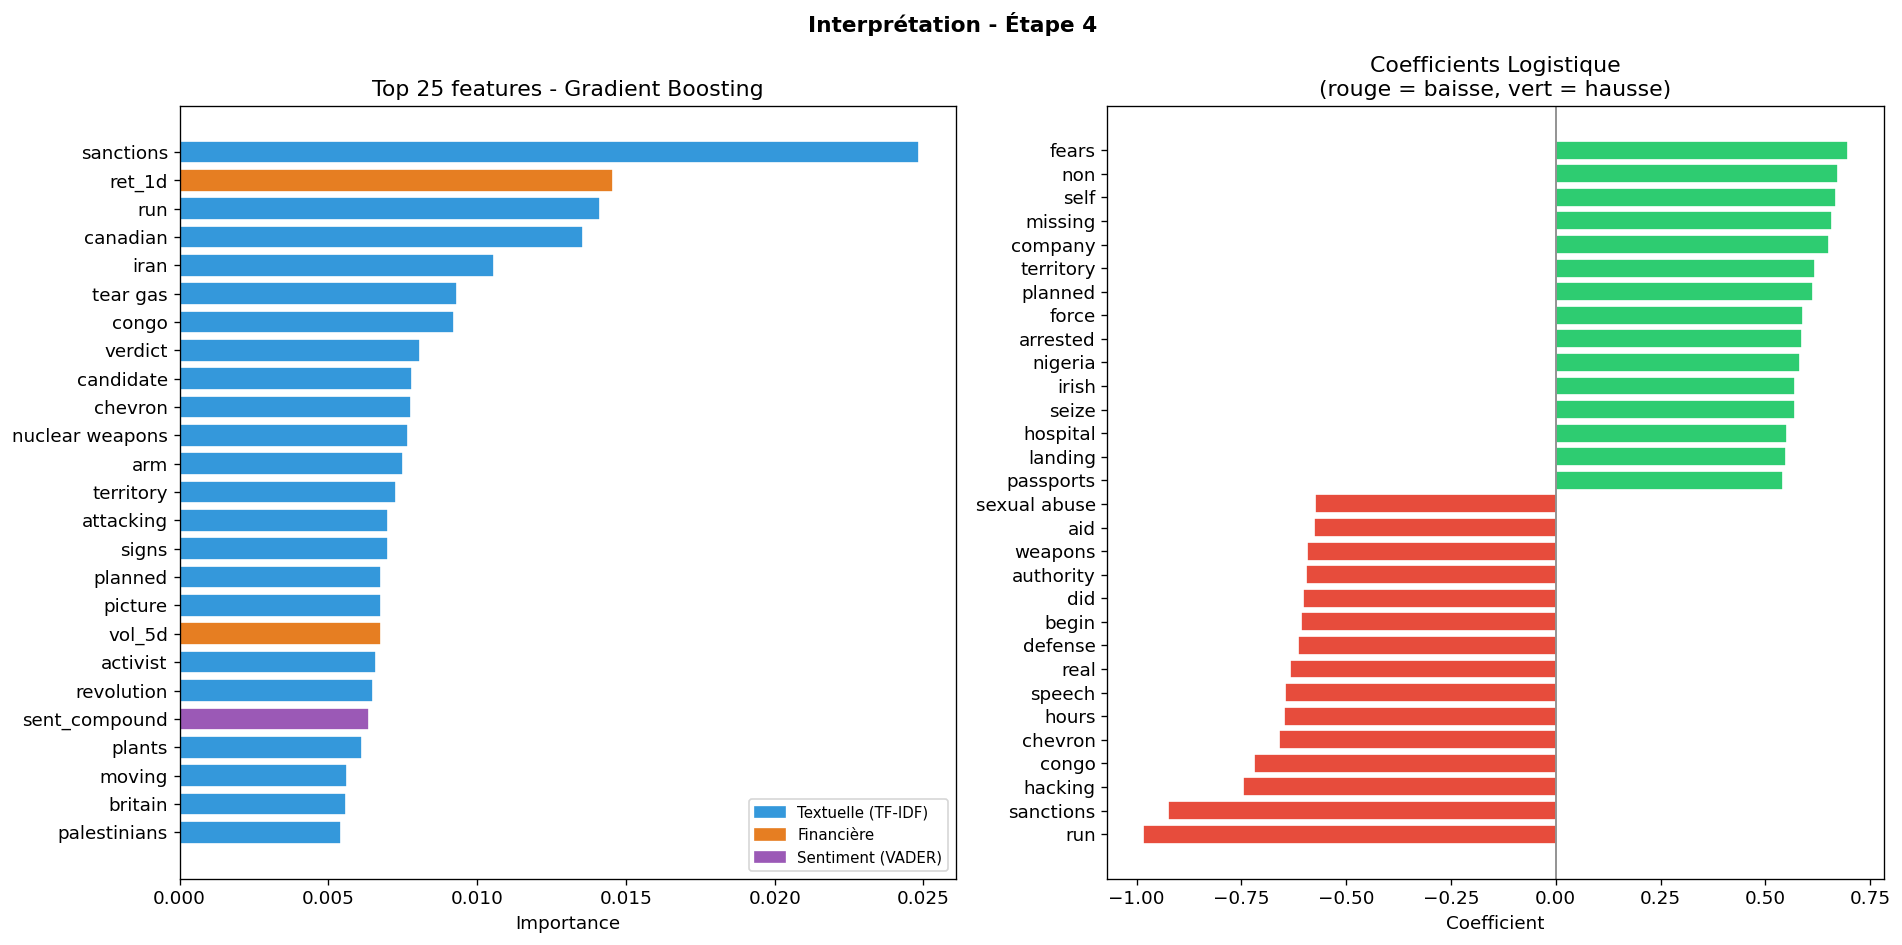

In [22]:
feature_names = np.array(
    list(tfidf.get_feature_names_out()) + fin_features + sent_features_cols
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Interprétation - Étape 4', fontsize=13, fontweight='bold')

# ── 1. Feature importance — Gradient Boosting ─────────────────────────────────
ax = axes[0]
gb_model   = final_models_n1['Gradient Boosting']['model']
importances = gb_model.feature_importances_
top25_idx   = np.argsort(importances)[-25:]

# Couleur selon type de feature
top25_names = feature_names[top25_idx]
bar_colors  = []
for name in top25_names:
    if name in fin_features:          bar_colors.append('#e67e22')   # orange = fin
    elif name in sent_features_cols:  bar_colors.append('#9b59b6')   # violet = sentiment
    else:                             bar_colors.append('#3498db')   # bleu = texte

ax.barh(top25_names, importances[top25_idx], color=bar_colors, edgecolor='white')
ax.set_title('Top 25 features - Gradient Boosting')
ax.set_xlabel('Importance')

# Légende
patches = [
    mpatches.Patch(color='#3498db', label='Textuelle (TF-IDF)'),
    mpatches.Patch(color='#e67e22', label='Financière'),
    mpatches.Patch(color='#9b59b6', label='Sentiment (VADER)'),
]
ax.legend(handles=patches, fontsize=9)

# ── 2. Coefficients — Régression Logistique ───────────────────────────────────
ax = axes[1]
lr_model = final_models_n1['Logistique']['model']
coefs    = lr_model.coef_[0]

# Top 15 positifs (hausse) et top 15 négatifs (baisse)
top15_pos = np.argsort(coefs)[-15:]
top15_neg = np.argsort(coefs)[:15]
all_idx   = np.concatenate([top15_neg, top15_pos])
all_names = feature_names[all_idx]
all_vals  = coefs[all_idx]
colors_lr = ['#e74c3c' if v < 0 else '#2ecc71' for v in all_vals]

ax.barh(all_names, all_vals, color=colors_lr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=1)
ax.set_title('Coefficients Logistique\n(rouge = baisse, vert = hausse)')
ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('etape4_interpretation.png', bbox_inches='tight', dpi=120)
plt.show()

**Feature importance - Gradient Boosting :**

- sanctions domine largement (importance ~0.025) : le mot le plus décisif de tout le modèle, reflétant l'impact des tensions géopolitiques sur les marchés
- ret_1d est la 2ème feature la plus importante (orange, ~0.015) : confirme que le rendement de la veille est un signal financier fort, plus puissant que la plupart des mots
- vol_5d et sent_compound apparaissent dans le top 25 : les features financières et sentiment apportent bien une information complémentaire au texte
- Le reste du top 25 est dominé par du vocabulaire géopolitique et conflictuel : "iran", "tear gas", "nuclear weapons", "attacking", "revolution" - cohérent avec un corpus Reddit/WorldNews

**Coefficients Logistique :**

- Baisse (rouge) : "run", "sanctions", "hacking", "congo", "defense", "weapons" -> vocabulaire de crise, conflits armés et cyberattaques
- Hausse (vert) : "fears", "non", "self", "missing", "company", "territory" -> termes difficiles à interpréter économiquement, signe que la régression logistique capte des corrélations spurieuses plutôt qu'un signal causal
- Les coefficients "Baisse" sont économiquement cohérents & les coefficients "Hausse" le sont beaucoup moins : ce déséquilibre d'interprétabilité est une limite importante du modèle
- Conclusion : le signal textuel est principalement un signal de risque géopolitique -> baisse PLUTOT qu'un signal positif structuré -> hausse

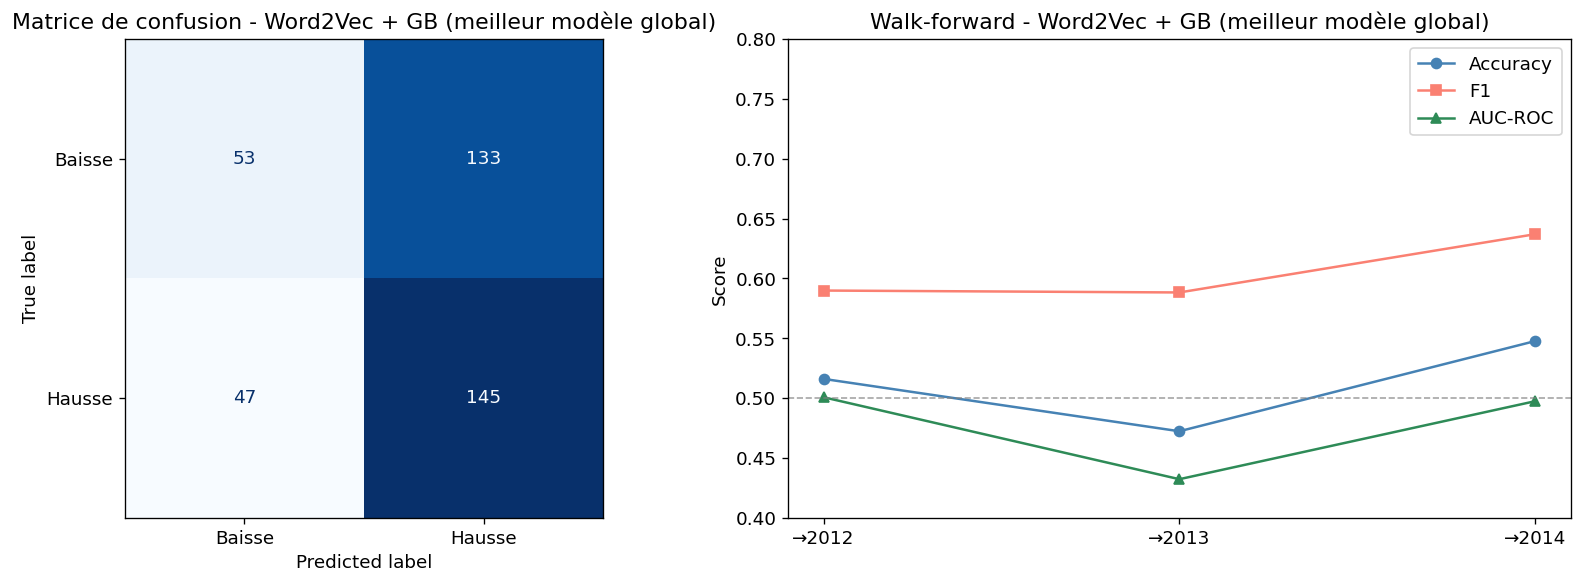

In [23]:
# ── Matrice de confusion du meilleur modèle global : Word2Vec + GB ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion - Word2Vec + GB (meilleur modèle toutes catégories)
cm = confusion_matrix(y_test, y_pred_w2v)
disp = ConfusionMatrixDisplay(cm, display_labels=['Baisse', 'Hausse'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion - Word2Vec + GB (meilleur modèle global)')

# Évolution des métriques walk-forward - Word2Vec + GB
ax = axes[1]
wf_w2v = walk_forward_eval(GradientBoostingClassifier,
                            {'n_estimators': 200, 'learning_rate': 0.05,
                             'max_depth': 4, 'random_state': 42},
                            df_full,
                            use_fin=True, use_sent=True)
x = range(len(wf_w2v))
ax.plot(x, wf_w2v['acc'], 'o-', label='Accuracy', color='steelblue')
ax.plot(x, wf_w2v['f1'],  's-', label='F1',       color='salmon')
ax.plot(x, wf_w2v['auc'], '^-', label='AUC-ROC',  color='seagreen')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(wf_w2v['window'])
ax.set_title('Walk-forward - Word2Vec + GB (meilleur modèle global)')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0.40, 0.80)

plt.tight_layout()
plt.savefig('etape4_confusion_walkforward.png', bbox_inches='tight', dpi=120)
plt.show()

**Matrice de confusion - Word2Vec + GB :**

- Le modèle prédit massivement "Hausse" : 132 + 148 = 280 prédictions hausse vs seulement 54 + 44 = 98 prédictions baisse -> biais encore plus marqué que le Gradient Boosting classique
- Vrais positifs hausse : 148 / Vrais positifs baisse : 54 -> le modèle détecte mieux la hausse que la baisse, cohérent avec le déséquilibre du dataset (53.5% hausse)
- 132 faux positifs (baisses prédites hausse) contre seulement 44 faux négatifs -> rater une baisse reste l'erreur dominante, particulièrement coûteuse en contexte de trading réel

**Walk-forward - Word2Vec + GB :**

- 2013 reste la fenêtre la plus difficile : AUC chute à 0.43 (sous le hasard) -> pattern identique au Gradient Boosting classique, confirme que 2013 est structurellement difficile à prédire
- 2012 et 2014 plus stables autour de 0.50 en AUC -> le modèle oscille autour du hasard sans jamais s'en détacher durablement
- Le F1 croît régulièrement (0.59 -> 0.64) pour la même mauvaise raison : prédiction croissante de "hausse" au fil du temps, pas une meilleure discrimination
- Conclusion : malgré de meilleures performances globales sur le test set, la walk-forward révèle que Word2Vec + GB souffre des mêmes instabilités temporelles -> le gain en AUC (0.550 vs 0.537) reste fragile et fenêtre-dépendant

---
# **Conclusion Générale / Récapitulatif Global**

### **Feature importance (Gradient Boosting)**

Les features les plus importantes reflètent 3 familles de signaux :

- **Financières** (ret_1d, vol_5d) : `ret_1d` est la 2ème feature la plus importante du modèle MAIS ATTENTION signal de **mean-reversion** (corrélation négative) et non de momentum comme initialement supposé

- **Sentiment** (sent_compound) : apparaît dans le top 25 mais avec une importance faible -> cohérent avec les distributions quasi-identiques hausse/baisse observées en étape 2

- **Textuelle** : `sanctions` domine largement l'ensemble des features (~0.025) PUIS s'en suit les mots géopolitiques ("iran", "tear gas", "nuclear weapons")

### **Coefficients Logistique**

- **Baisse** : vocabulaire de crise géopolitique ("run", "sanctions", "hacking", "congo", "defense", "weapons") -> économiquement cohérent, reflète l'impact de l'incertitude géopolitique sur les marchés

- **Hausse** : vocabulaire difficile à interpréter ("fears", "non", "self", "missing", "company") -> corrélations spurieuses plutôt qu'un signal causal structuré

### **Matrice de confusion & Walk-forward - Word2Vec + GB (meilleur modèle global)**

- **Biais structurel massif** : 280 prédictions hausse vs 98 baisse -> le modèle ne discrimine pas équitablement les deux classes malgré une Accuracy de 0.534

- **2013 systématiquement difficile** pour tous les modèles (AUC < 0.45) -> signal absent ou trop bruité cette année-là, quelle que soit la représentation textuelle utilisée

- **Instabilité temporelle confirmée** : les performances sont fenêtre-dépendantes, ce qui fragilise tout déploiement réel du modèle

### **Limites du modèle / Sélection des hyperparamètres**

- **Set de validation** (2014 / 252 jours) **sous-exploité pour N1 et N2** : les hyperparamètres ont été fixés manuellement plutôt que sélectionnés via une recherche systématique sur val

- **Hyperparamètres** : fixés manuellement (n_estimators=200, lr=0.05, max_depth=4) sont des **valeurs standards bien calibrées** dans la littérature pour ce type de problème

- Un **tuning propre** aurait pu apporter **1-2% d'AUC supplémentaire** mais sans changer les conclusions fondamentales : le signal reste intrinsèquement faible quelle que soit la configuration

- La **vraie limite** n'est pas technique : c'est la qualité du dataset -> des données Reddit/WorldNews restent un proxy imparfait des marchés financiers, et aucun tuning d'hyperparamètres ne peut créer du signal là où il n'existe pas structurellement

- L'**instabilité temporelle** observée en walk-forward (particulièrement en 2013, systématiquement sous le hasard) confirme que le problème est lié aux données, pas aux choix de modélisation